In [1]:
# IMPORTS AND SETUP
import os
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cf
import easygems.healpix as egh
from pathlib import Path
import warnings
import intake
from pyflextrkr.ft_utilities import load_config
from pyflextrkr.ftfunctions import olr_to_tb
warnings.filterwarnings('ignore')

# Set figure parameters
plt.rcParams['figure.dpi'] = 144
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# source_name = "scream"
# # source_name = "IMERGv7"
# # source_name = "icon_d3hp003"
# # source_name = "casesm2_10km_nocumulus"
# root_dir = f"/pscratch/sd/w/wcmca1/hackathon/cof_masks/"
# # in_dir = f"{root_dir}/{source_name}_cofmasks_hp8_v1.zarr"
# in_dir = f"{root_dir}/{source_name}_cofmasks_hp8_v1.zarr"
# figdir = f"/global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_cof/tmp/"
# os.makedirs(figdir, exist_ok=True)

# # Load the processed dataset
# print(f"Loading data from: {in_dir}")

# # ds = xr.open_dataset(in_dir)
# ds = xr.open_zarr(in_dir, mask_and_scale=False, consolidated=True)
# # ds = xr.open_dataset(in_dir, engine='zarr')
# ds = ds.pipe(egh.attach_coords)
# ds

In [3]:
# source = "scream"
# # source = "nicam_gl11"
# # source = "um_glm_n2560_RAL3p3"
# # source = "icon_d3hp003"
# # source = "ifs_tco3999_rcbmf"
# # source = "casesm2_10km_nocumulus"
# # source = "IMERGv7"

# # MCS masks
# root_dir = "/pscratch/sd/w/wcmca1/hackathon/mcs_masks/"
# in_zarr = f"{root_dir}{source}_mcs_masks_hp8.zarr"
# print(in_zarr)

# ds = xr.open_zarr(in_zarr, mask_and_scale=False, consolidated=True)
# ds

In [4]:
config_dir = "/global/homes/f/feng045/program/waccem/gsrm_cooccurrencefeature/config/"
config_file = f"{config_dir}config_mcs_tbpf_scream.yml"

zoom = 8
config = load_config(config_file)
root_path = config.get("root_path")
pixel_path_name = config.get("pixel_path_name")
pixel_path = f"{root_path}{pixel_path_name}/"
in_basename = config.get("zarr_output_presets", {}).get("healpix").get("out_filebase")
in_zarr = f"{pixel_path}{in_basename}hp{zoom}_v1.zarr"

# Precipitation variable names and conversion factor
varname_precip_liq = 'pr'
varname_precip_ice = 'prs'
pr_convert_factor = config.get('pcp_convert_factor')
pr_convert_factor

3600000.0

In [27]:
# Get source name from root path (e.g., /pscratch/sd/w/wcmca1/hackathon/mcs/scream/)
source_name = os.path.basename(os.path.normpath(root_path))

ds = xr.open_zarr(in_zarr, consolidated=True, mask_and_scale=False)
ds = ds.pipe(egh.attach_coords)
ds

<xarray.Dataset> Size: 119GB
Dimensions:   (time: 9456, cell: 786432)
Coordinates:
  * time      (time) datetime64[ns] 76kB 2019-08-01T01:00:00 ... 2020-09-01
    crs       int64 8B 0
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    ccs_mask  (time, cell) int64 59GB dask.array<chunksize=(24, 65536), meta=np.ndarray>
    mcs_mask  (time, cell) int64 59GB dask.array<chunksize=(24, 65536), meta=np.ndarray>
Attributes: (12/15)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Mon May  5 10:42:36 2025
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    pf_smooth_window:          5
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [28]:
# Catalog
source = 'scream2D_hrly'
# zoom = 8
catalog_file = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
catalog_location = 'NERSC'
# catalog_location = 'online'
catalog_params = {
    'zoom': 8,
    # 'time': 'PT3H',
    # 'time': 'PT1H',
}

# Load catalog
cat = intake.open_catalog(catalog_file)[catalog_location]
ds_p = cat[source](**catalog_params).to_dask()
ds_p

<xarray.Dataset> Size: 60GB
Dimensions:   (crs: 0, time: 9457, cell: 786432)
Coordinates:
  * crs       (crs) float64 0B 
  * time      (time) object 76kB 2019-08-01 00:00:00 ... 2020-09-01 00:00:00
Dimensions without coordinates: cell
Data variables:
    pr        (time, cell) float32 30GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    rlut      (time, cell) float32 30GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    ELEV      (cell) float32 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
    LANDFRAC  (cell) float32 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
    lat       (cell) float32 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
    lon       (cell) float32 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                  CF-1.8
    atm_initial_conditions_file:  /lustre/orion/cli115/world-shared/e3sm/inpu...
    averaging_frequency:          1
    averaging_frequency_units:    nhours
    averaging_type:               INSTANT
    case:                         cess-control.ne1024pg2_ne1024pg2.F2010-SCRE...
    ...                           ...
    product:                      model-output
    realm:                        atmos
    run_t0:                       2019-08-01-00000
    source:                       E3SM Atmosphere Model (EAMxx)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel

In [29]:
# Check liquid precipitaiton variable
if varname_precip_liq in list(ds_p.keys()):
    # Convert liquid precipitation to mm/h
    pr = ds_p[varname_precip_liq] * pr_convert_factor
# Check if the ice precipitation variable exist in the dataset
if varname_precip_ice in list(ds_p.keys()):
    # Convert ice precipitation to liquid equivalent
    prs = ds_p[varname_precip_ice] * pr_convert_factor
    # Add ice precipitation to get total precipitation
    pr = pr + prs

In [30]:
# Determine calendar types
ds_p_calendar_type = type(ds_p.time.values[0]).__name__
ds_calendar_type = type(ds.time.values[0]).__name__

print(f"Dataset calendars: ds_p uses {ds_p_calendar_type}, ds uses {ds_calendar_type}")

# Convert ds time to match ds_p if they differ
if ds_calendar_type != ds_p_calendar_type:
    print(f"Converting ds time from {ds_calendar_type} to {ds_p_calendar_type}")
    
    # Get the calendar details from ds_p
    has_year_zero = True
    if hasattr(ds_p.time.values[0], 'has_year_zero'):
        has_year_zero = ds_p.time.values[0].has_year_zero
    
    # Convert datetime64 values to cftime DatetimeNoLeap objects
    new_times = []
    for t in ds.time.values:
        # Convert numpy datetime64 to pandas Timestamp to get date components
        pd_time = pd.Timestamp(t)
        # Create a matching cftime object
        dt_cftime = cftime.DatetimeNoLeap(
            pd_time.year, pd_time.month, pd_time.day,
            pd_time.hour, pd_time.minute, pd_time.second,
            has_year_zero=has_year_zero
        )
        new_times.append(dt_cftime)
    
    # Create a new dataset with the converted time coordinate
    ds = ds.assign_coords(time=new_times)
    print("Calendar conversion complete")

# Find common time range across all datasets
common_times = sorted(set(ds_p['time'].values)
                        .intersection(set(ds['time'].values)))
if not common_times:
    print("No common time values between all datasets!")
    # return None
else:
    # Select only the common times in all datasets
    pr = pr.sel(time=common_times)
    ds = ds.sel(time=common_times)
    # Add precipitation to the dataset
    ds["pr"] = pr
    # Convert OLR to Tb and add to dataset
    ds["tb"] = olr_to_tb(ds_p["rlut"])
    print(f"Successfully merged datasets with {len(common_times)} common time points")

Dataset calendars: ds_p uses DatetimeNoLeap, ds uses datetime64
Converting ds time from datetime64 to DatetimeNoLeap
Calendar conversion complete
Successfully merged datasets with 9456 common time points


In [31]:
ds

<xarray.Dataset> Size: 178GB
Dimensions:   (cell: 786432, time: 9456)
Coordinates:
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
  * time      (time) object 76kB 2019-08-01 01:00:00 ... 2020-09-01 00:00:00
    crs       int64 8B 0
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    ccs_mask  (time, cell) int64 59GB dask.array<chunksize=(24, 65536), meta=np.ndarray>
    mcs_mask  (time, cell) int64 59GB dask.array<chunksize=(24, 65536), meta=np.ndarray>
    pr        (time, cell) float32 30GB dask.array<chunksize=(23, 262144), meta=np.ndarray>
    tb        (time, cell) float32 30GB dask.array<chunksize=(23, 262144), meta=np.ndarray>
Attributes: (12/15)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Mon May  5 10:42:36 2025
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    pf_smooth_window:          5
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [32]:
itime = 50
_ds = ds.isel(time=itime)
_ds

<xarray.Dataset> Size: 38MB
Dimensions:   (cell: 786432)
Coordinates:
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    time      object 8B 2019-08-03 03:00:00
    crs       int64 8B 0
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    ccs_mask  (cell) int64 6MB dask.array<chunksize=(65536,), meta=np.ndarray>
    mcs_mask  (cell) int64 6MB dask.array<chunksize=(65536,), meta=np.ndarray>
    pr        (cell) float32 3MB dask.array<chunksize=(262144,), meta=np.ndarray>
    tb        (cell) float32 3MB dask.array<chunksize=(262144,), meta=np.ndarray>
Attributes: (12/15)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Mon May  5 10:42:36 2025
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    pf_smooth_window:          5
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [44]:
lon = _ds['lon'].load()
lat = _ds['lat'].load()
tb = _ds['tb'].load()
pr = _ds['pr'].load()
mcs_mask = _ds['mcs_mask'].load()
ccs_mask = _ds['ccs_mask'].load()

In [38]:
# Remove MCS from CCS mask
nmcs_ccs_mask = ccs_mask.where(mcs_mask == 0)

<Figure size 921.6x691.2 with 0 Axes>

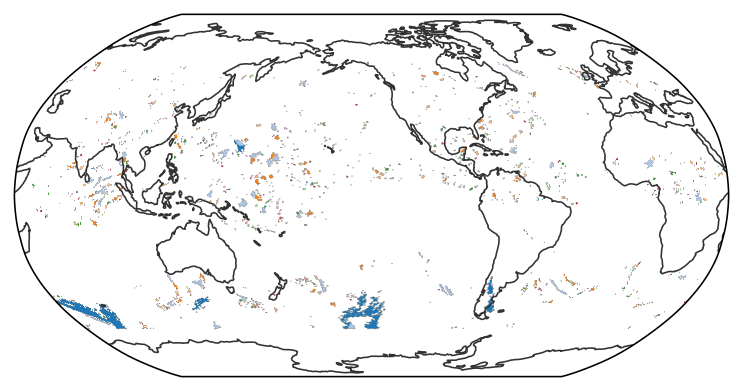

In [43]:
egh.healpix_show(nmcs_ccs_mask.where(nmcs_ccs_mask>0), cmap='tab20')

<Figure size 921.6x691.2 with 0 Axes>

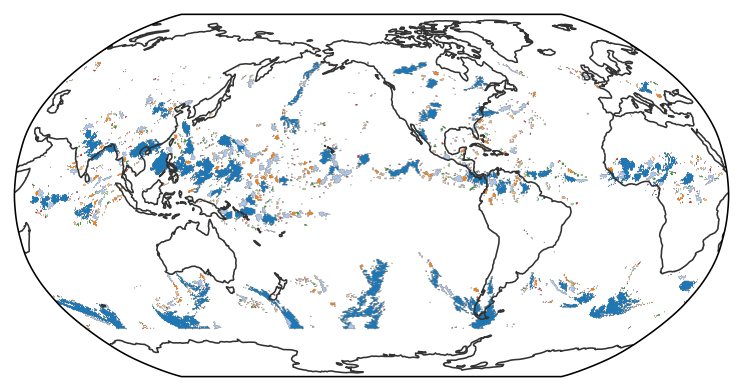

In [42]:
egh.healpix_show(ccs_mask.where(ccs_mask>0), cmap='tab20')

## Cloud Type Classification Setup

Create latitude-dependent brightness temperature thresholds for cloud classification:
- **Tropics** (-30° to 30°): Fixed threshold at 250 K
- **Mid-latitudes** (30° to 60°): Linearly decrease from 250 K to 230 K
- **High latitudes** (>60°): Below 230 K (optional handling)

In [45]:
# Extract latitude values (matching the cell dimension)
lat = ds['lat'].values
abs_lat = np.abs(lat)

# Initialize tb_thresh array with zeros
tb_thresh = np.zeros_like(lat, dtype=np.float32)

# Define the thresholds for different latitude bands
# Tropics: -30 <= lat <= 30, tb_thresh = 250 K
tropical_mask = abs_lat <= 30
tb_thresh[tropical_mask] = 250.0

# Mid-latitudes: 30 < |lat| <= 60, linearly decrease from 250 to 230 K
# Formula: tb_thresh = 250 - 20 * ((|lat| - 30) / 30)
midlat_mask = (abs_lat > 30) & (abs_lat <= 60)
tb_thresh[midlat_mask] = 250.0 - 20.0 * ((abs_lat[midlat_mask] - 30.0) / 30.0)

# High latitudes: |lat| > 60, tb_thresh = 230 K (extrapolated)
highlat_mask = abs_lat > 60
tb_thresh[highlat_mask] = 230.0

# Create an xarray DataArray for tb_thresh with proper coordinates
tb_thresh_da = xr.DataArray(
    tb_thresh,
    dims=['cell'],
    coords={'cell': ds['cell'], 'lat': ds['lat'], 'lon': ds['lon']},
    name='tb_thresh',
    attrs={
        'long_name': 'Latitude-dependent brightness temperature threshold',
        'units': 'K',
        'description': 'Tropics (|lat|<=30): 250K; Mid-lat (30<|lat|<=60): 250-230K linear; High-lat (|lat|>60): 230K'
    }
)

print(f"✅ tb_thresh array created")
print(f"   Shape: {tb_thresh.shape}")
print(f"   Min: {tb_thresh.min():.2f} K, Max: {tb_thresh.max():.2f} K")
print(f"   Tropical cells (|lat|<=30°): {tropical_mask.sum():,}")
print(f"   Mid-latitude cells (30°<|lat|<=60°): {midlat_mask.sum():,}")
print(f"   High-latitude cells (|lat|>60°): {highlat_mask.sum():,}")

✅ tb_thresh array created
   Shape: (786432,)
   Min: 230.00 K, Max: 250.00 K
   Tropical cells (|lat|<=30°): 393,216
   Mid-latitude cells (30°<|lat|<=60°): 287,592
   High-latitude cells (|lat|>60°): 105,624


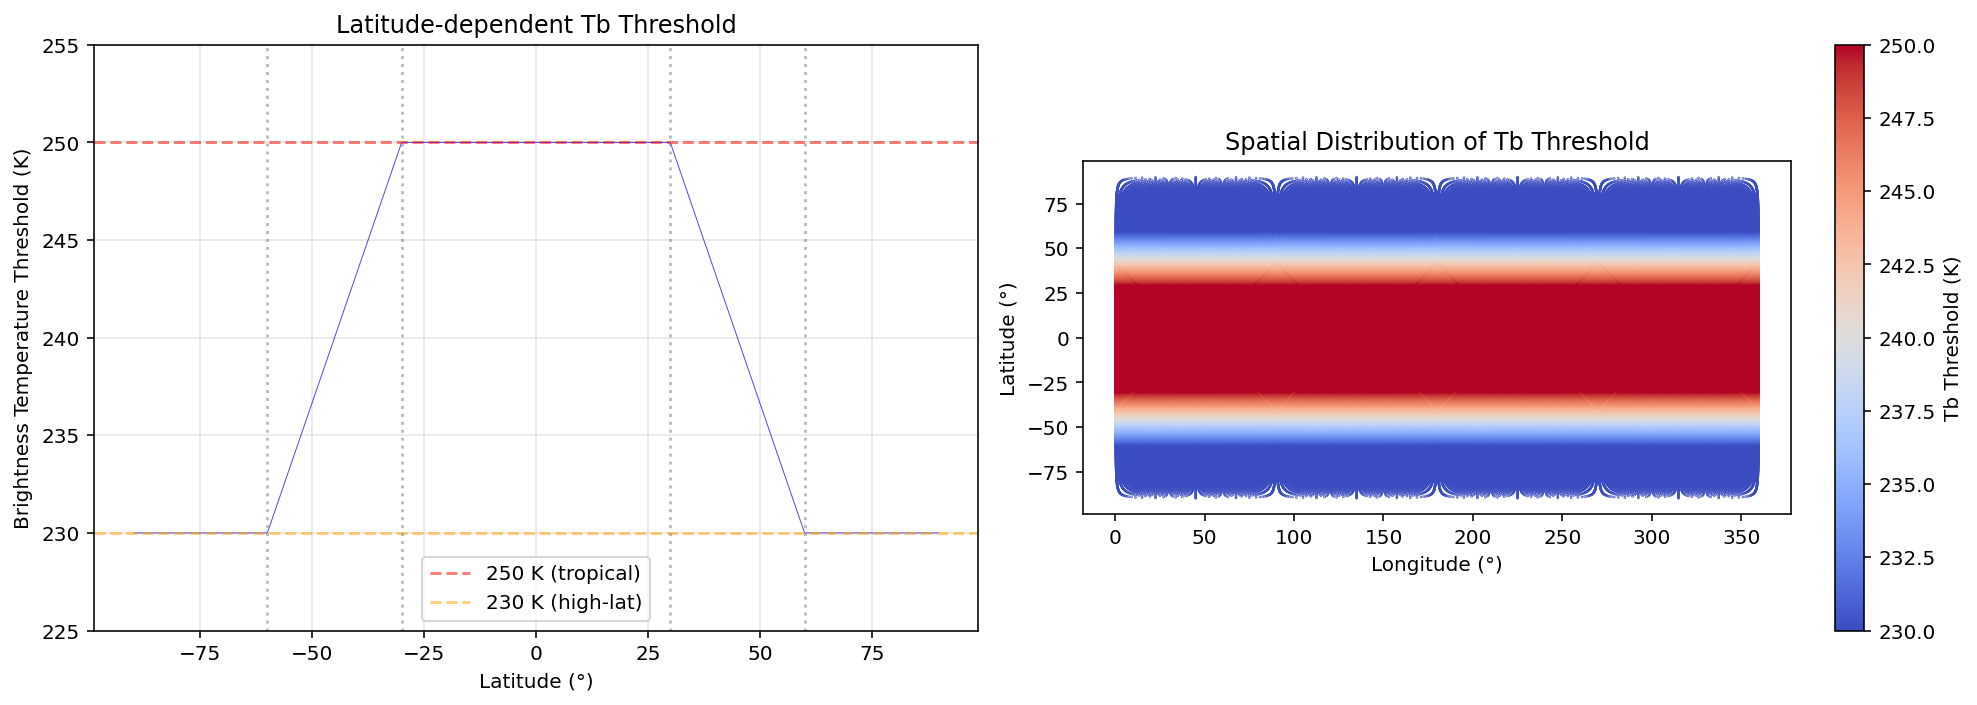

Threshold statistics by latitude band:
  Tropics:      250.00 - 250.00 K
  Mid-latitudes: 230.09 - 250.00 K
  High-latitudes: 230.00 - 230.00 K


In [46]:
# Visualize the latitude-dependent threshold distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Threshold as a function of latitude
ax = axes[0]
# Sort by latitude for clean plotting
sort_idx = np.argsort(lat)
ax.plot(lat[sort_idx], tb_thresh[sort_idx], 'b-', linewidth=0.5, alpha=0.7)
ax.axhline(250, color='r', linestyle='--', alpha=0.5, label='250 K (tropical)')
ax.axhline(230, color='orange', linestyle='--', alpha=0.5, label='230 K (high-lat)')
ax.axvline(-30, color='gray', linestyle=':', alpha=0.5)
ax.axvline(30, color='gray', linestyle=':', alpha=0.5)
ax.axvline(-60, color='gray', linestyle=':', alpha=0.5)
ax.axvline(60, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Latitude (°)')
ax.set_ylabel('Brightness Temperature Threshold (K)')
ax.set_title('Latitude-dependent Tb Threshold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(225, 255)

# Plot 2: Spatial distribution on HEALPix grid
ax = axes[1]
scatter = ax.scatter(lon, lat, c=tb_thresh, s=0.1, cmap='coolwarm', vmin=230, vmax=250)
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Spatial Distribution of Tb Threshold')
ax.set_aspect('equal')
cbar = plt.colorbar(scatter, ax=ax, label='Tb Threshold (K)')

plt.tight_layout()
plt.show()

print(f"Threshold statistics by latitude band:")
print(f"  Tropics:      {tb_thresh[tropical_mask].min():.2f} - {tb_thresh[tropical_mask].max():.2f} K")
print(f"  Mid-latitudes: {tb_thresh[midlat_mask].min():.2f} - {tb_thresh[midlat_mask].max():.2f} K")
print(f"  High-latitudes: {tb_thresh[highlat_mask].min():.2f} - {tb_thresh[highlat_mask].max():.2f} K")

## Cloud Type Classification Function

Classify non-MCS clouds into 4 types based on brightness temperature and precipitation:
1. **Deep Convective**: Tb < threshold AND precipitation ≥ 0.5 mm/h
2. **Non-deep Convective**: Tb ≥ threshold AND precipitation ≥ 0.5 mm/h  
3. **Stratiform Cloud**: Tb < threshold AND precipitation < 0.5 mm/h
4. **Drizzle**: Tb ≥ threshold AND precipitation < 0.5 mm/h

Classification only applied where non-MCS CCS mask > 0.

In [54]:
def classify_cloud_types(tb, pr, tb_thresh, nonmcs_ccs_mask, pr_threshold=0.5):
    """
    Classify cloud types based on brightness temperature and precipitation.
    
    Parameters
    ----------
    tb : xarray.DataArray
        Brightness temperature (K)
    pr : xarray.DataArray
        Precipitation rate (mm/h)
    tb_thresh : xarray.DataArray or numpy.ndarray
        Latitude-dependent brightness temperature threshold (K)
    nonmcs_ccs_mask : xarray.DataArray
        Non-MCS CCS mask (only classify where > 0)
    pr_threshold : float, optional
        Precipitation threshold for classification (default: 0.5 mm/h)
    
    Returns
    -------
    cloud_type : xarray.DataArray
        Cloud type classification:
        0 = No cloud (or outside nonmcs_ccs_mask)
        1 = Deep convective
        2 = Non-deep convective
        3 = Drizzle
    """
    # Initialize cloud type array with zeros
    cloud_type = xr.zeros_like(tb, dtype=np.int8)
    
    # Only classify where nonmcs_ccs_mask > 0
    valid_mask = nonmcs_ccs_mask > 0
    
    # Classification conditions (only applied where valid_mask is True)
    # 1. Deep convective: tb < tb_thresh & pr >= pr_threshold
    # deep_conv = (tb < tb_thresh) & (pr >= pr_threshold) & valid_mask
    deep_conv = (tb < tb_thresh) & valid_mask
    cloud_type = cloud_type.where(~deep_conv, 1)
    
    # 2. Non-deep convective: tb >= tb_thresh & pr >= pr_threshold
    nondeep_conv = (tb >= tb_thresh) & (pr >= pr_threshold) & valid_mask
    cloud_type = cloud_type.where(~nondeep_conv, 2)
    
    # # 3. Stratiform cloud: tb < tb_thresh & pr < pr_threshold
    # stratiform = (tb < tb_thresh) & (pr < pr_threshold) & valid_mask
    # cloud_type = cloud_type.where(~stratiform, 3)
    
    # 3. Drizzle: tb >= tb_thresh & pr < pr_threshold
    drizzle = (tb >= tb_thresh) & (pr < pr_threshold) & valid_mask
    cloud_type = cloud_type.where(~drizzle, 3)
    
    # Add metadata
    cloud_type.name = 'cloud_type'
    cloud_type.attrs = {
        'long_name': 'Cloud type classification',
        'units': 'category',
        'flag_values': [0, 1, 2, 3],
        'flag_meanings': 'no_cloud deep_convective non-deep_convective drizzle',
        'description': f'Classification based on Tb threshold and precipitation >= {pr_threshold} mm/h',
        'note': 'Only classified where non-MCS CCS mask > 0'
    }
    
    return cloud_type

print("✅ Cloud type classification function created")

✅ Cloud type classification function created


In [55]:
# Apply classification to the single time step data
cloud_type = classify_cloud_types(tb, pr, tb_thresh_da, nmcs_ccs_mask, pr_threshold=0.5)

# Print statistics
print(f"\n📊 Cloud Type Statistics (Time step {itime}):")
print(f"   Total cells in dataset: {cloud_type.size:,}")
print(f"   Non-MCS CCS cells: {(nmcs_ccs_mask > 0).sum().values:,}")
print(f"\nCloud type counts:")
for i, label in enumerate(['No cloud/Outside mask', 'Deep convective', 
                            'Non-deep convective', 'Stratiform cloud', 'Drizzle']):
    count = (cloud_type == i).sum().values
    pct = 100 * count / cloud_type.size
    print(f"   {i}. {label:25s}: {count:8,} ({pct:5.2f}%)")
    
# Among classified clouds only
classified = (cloud_type > 0).sum().values
if classified > 0:
    print(f"\nPercentages among classified clouds only ({classified:,} cells):")
    for i, label in enumerate(['Deep convective', 'Non-deep convective', 
                                'Stratiform cloud', 'Drizzle'], start=1):
        count = (cloud_type == i).sum().values
        pct = 100 * count / classified
        print(f"   {i}. {label:25s}: {count:8,} ({pct:5.2f}%)")


📊 Cloud Type Statistics (Time step 50):
   Total cells in dataset: 786,432
   Non-MCS CCS cells: 17,107

Cloud type counts:
   0. No cloud/Outside mask    :  769,325 (97.82%)
   1. Deep convective          :   13,116 ( 1.67%)
   2. Non-deep convective      :      806 ( 0.10%)
   3. Stratiform cloud         :    3,185 ( 0.40%)
   4. Drizzle                  :        0 ( 0.00%)

Percentages among classified clouds only (17,107 cells):
   1. Deep convective          :   13,116 (76.67%)
   2. Non-deep convective      :      806 ( 4.71%)
   3. Stratiform cloud         :    3,185 (18.62%)
   4. Drizzle                  :        0 ( 0.00%)


<Figure size 921.6x691.2 with 0 Axes>

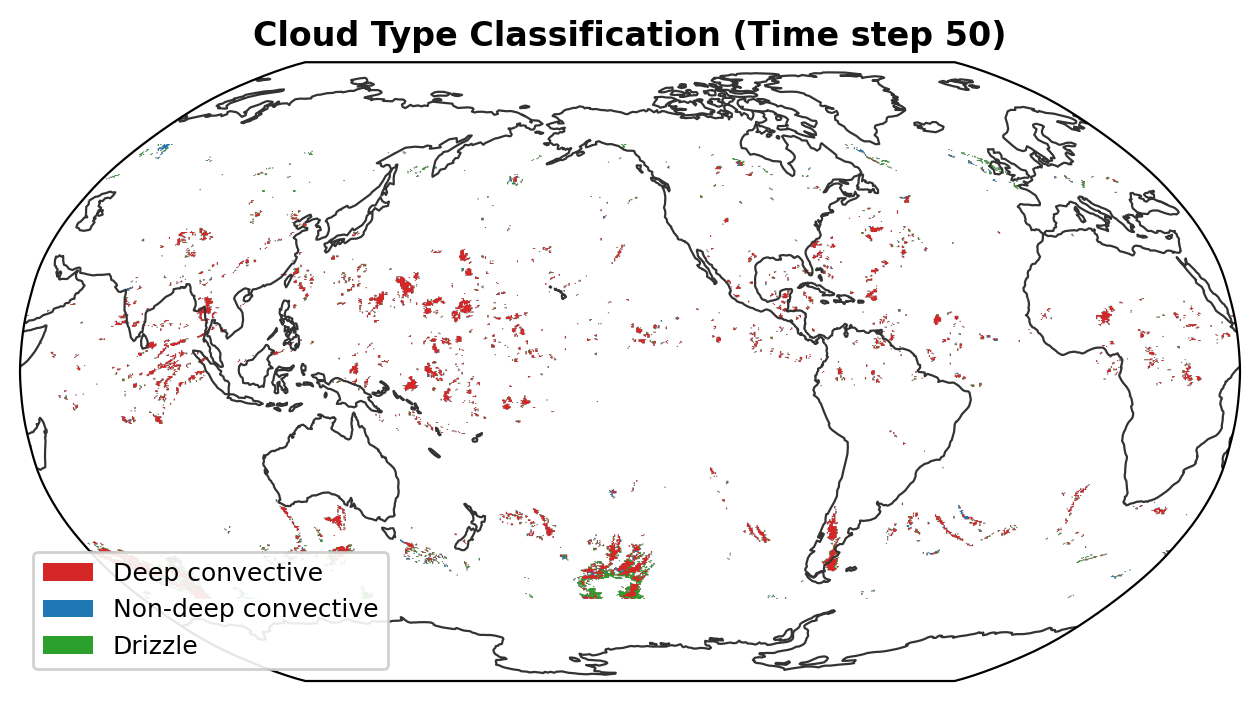

<Figure size 921.6x691.2 with 0 Axes>

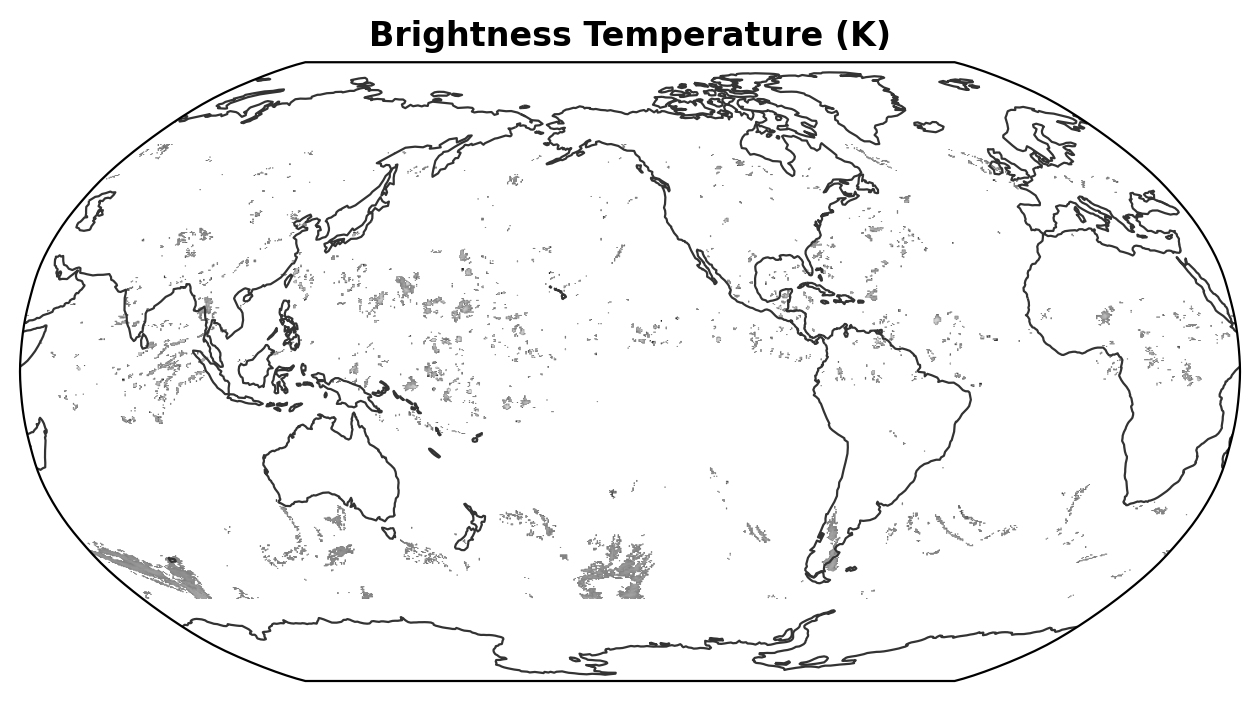

<Figure size 921.6x691.2 with 0 Axes>

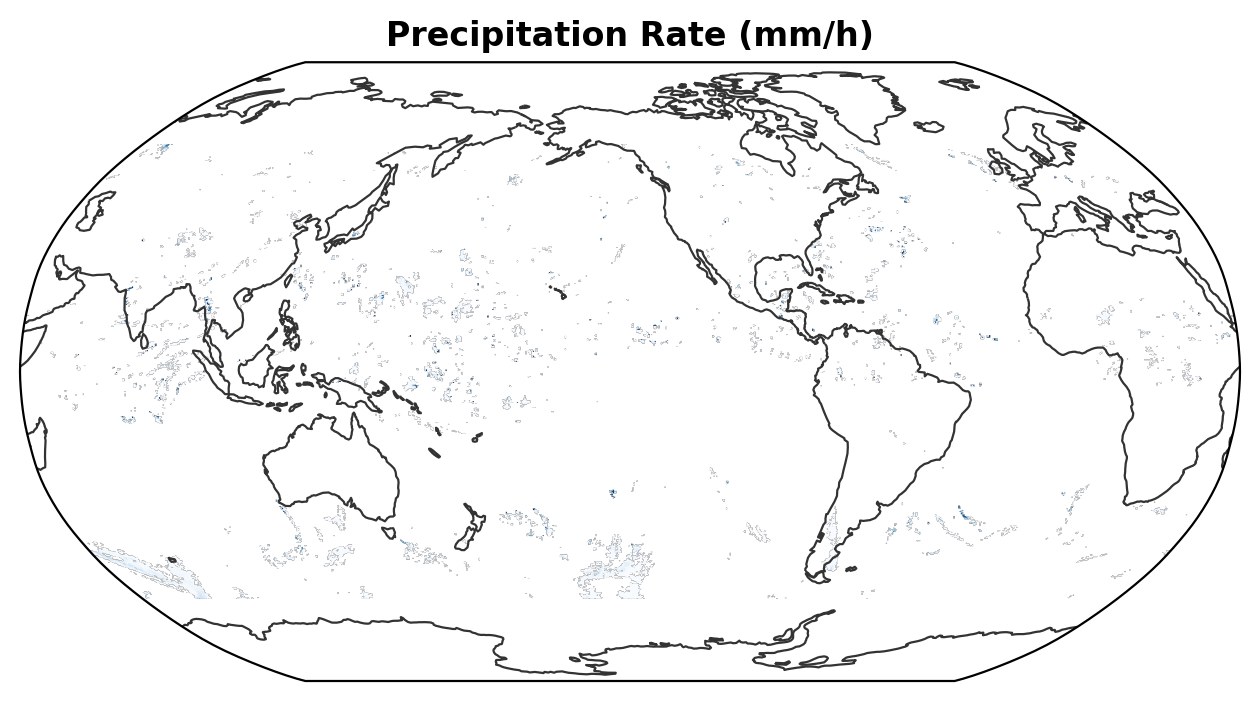

<Figure size 921.6x691.2 with 0 Axes>

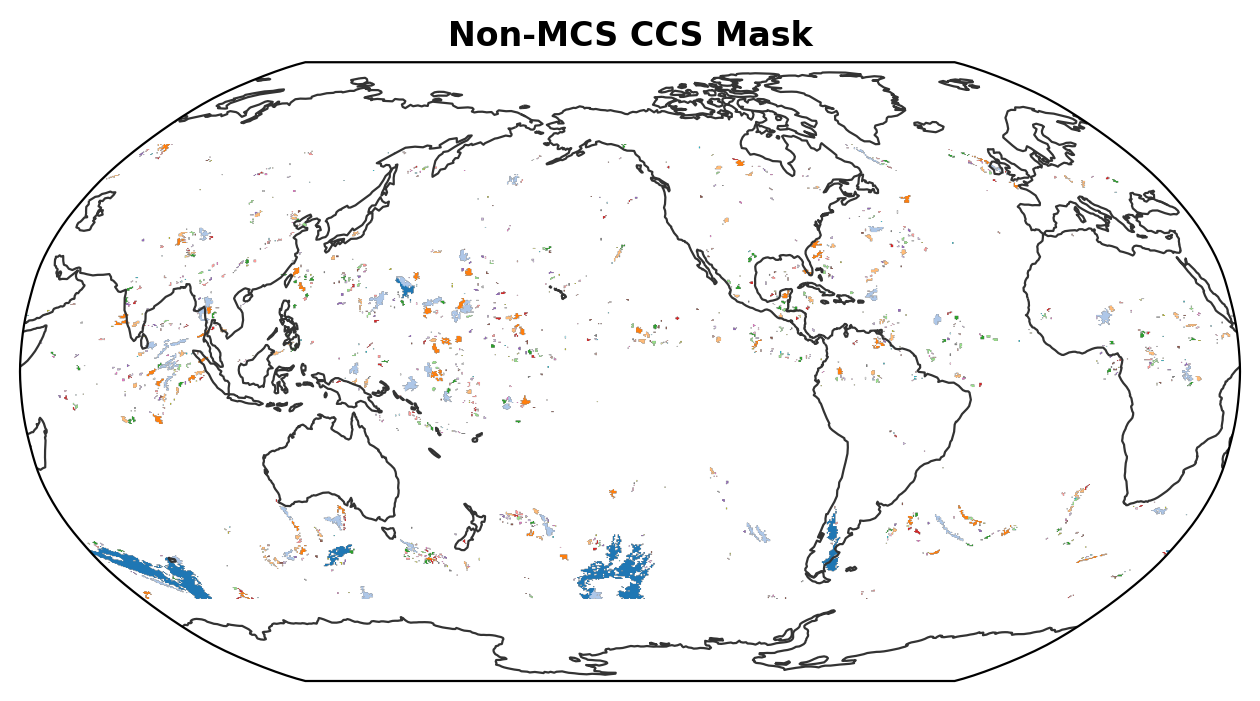

In [57]:
# Visualize cloud type classification
# Define colors and labels for cloud types
cloud_colors = {
    0: '#ffffff',  # No cloud - white
    1: '#d62728',  # Deep convective - red
    2: '#1f77b4',  # Non-deep convective - orange
    3: '#2ca02c',  # Drizzle - green
}
cloud_labels = {
    0: 'No cloud',
    1: 'Deep convective',
    2: 'Non-deep convective',
    3: 'Drizzle'
}
dpi = 200

# Plot 1: Cloud type classification
ax1 = egh.healpix_show(cloud_type.where(cloud_type > 0), 
                       cmap=mpl.colors.ListedColormap([cloud_colors[i] for i in range(1, 4)]),
                       vmin=0.5, vmax=3.5,
                       dpi=dpi)
plt.title(f'Cloud Type Classification (Time step {itime})', fontsize=12, fontweight='bold')
# Create custom legend
legend_elements = [Patch(facecolor=cloud_colors[i], label=cloud_labels[i]) 
                   for i in range(1, 4)]
plt.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

# Plot 2: Brightness temperature
ax2 = egh.healpix_show(tb.where(nmcs_ccs_mask > 0), cmap='gray_r', vmin=180, vmax=300, dpi=dpi)
plt.title('Brightness Temperature (K)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 3: Precipitation
ax3 = egh.healpix_show(pr.where(nmcs_ccs_mask > 0), cmap='Blues', vmin=0, vmax=10, dpi=dpi)
plt.title('Precipitation Rate (mm/h)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 4: Non-MCS CCS mask
ax4 = egh.healpix_show(nmcs_ccs_mask.where(nmcs_ccs_mask > 0), cmap='tab20', dpi=dpi)
plt.title('Non-MCS CCS Mask', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

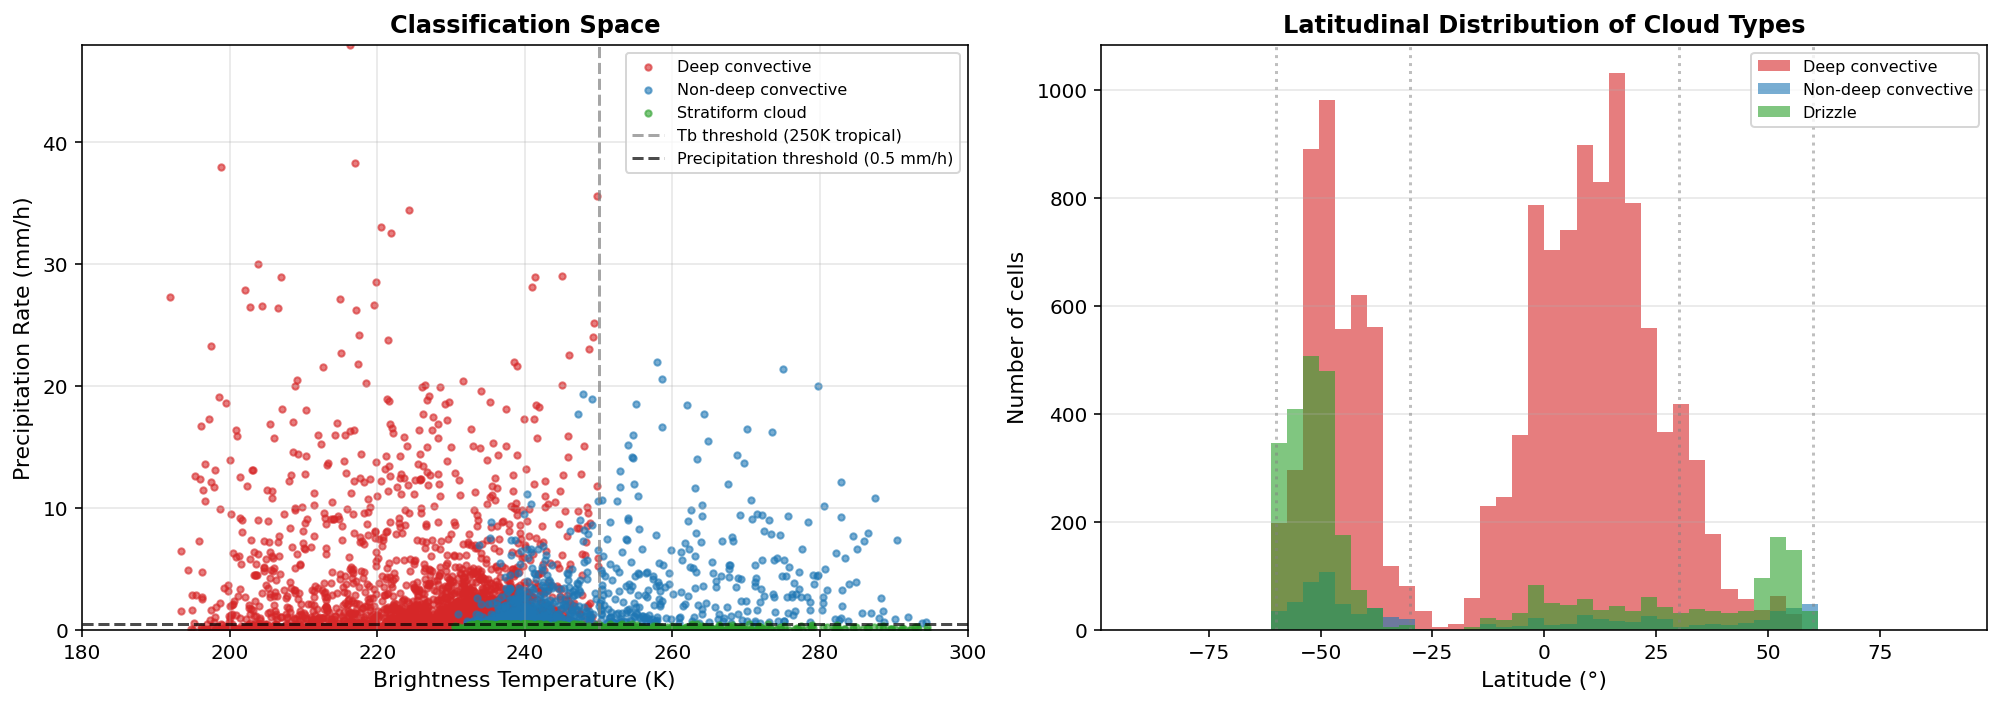

In [58]:
# Create a detailed summary plot showing classification logic
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Scatter plot of Tb vs Precipitation (colored by cloud type)
ax = axes[0]
# Get data for classified clouds only
classified_idx = cloud_type.values > 0
if classified_idx.sum() > 0:
    tb_vals = tb.values[classified_idx]
    pr_vals = pr.values[classified_idx]
    ct_vals = cloud_type.values[classified_idx]
    lat_vals = lat[classified_idx]
    
    # Plot each cloud type
    for i, label in enumerate(['Deep convective', 'Non-deep convective', 
                                'Stratiform cloud', 'Drizzle'], start=1):
        mask = ct_vals == i
        if mask.sum() > 0:
            ax.scatter(tb_vals[mask], pr_vals[mask], 
                      c=cloud_colors[i], s=10, alpha=0.6, label=label)
    
    # Add threshold lines
    ax.axvline(250, color='gray', linestyle='--', linewidth=1.5, 
               alpha=0.7, label='Tb threshold (250K tropical)')
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1.5, 
               alpha=0.7, label='Precipitation threshold (0.5 mm/h)')
    
    ax.set_xlabel('Brightness Temperature (K)', fontsize=11)
    ax.set_ylabel('Precipitation Rate (mm/h)', fontsize=11)
    ax.set_title('Classification Space', fontsize=12, fontweight='bold')
    ax.set_xlim(180, 300)
    ax.set_ylim(0, max(15, pr_vals.max()))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

# Right plot: Distribution by latitude
ax = axes[1]
for i, label in enumerate(['Deep convective', 'Non-deep convective', 'Drizzle'], start=1):
    mask = ct_vals == i
    if mask.sum() > 0:
        ax.hist(lat_vals[mask], bins=50, color=cloud_colors[i], 
                alpha=0.6, label=label, range=(-90, 90))

ax.set_xlabel('Latitude (°)', fontsize=11)
ax.set_ylabel('Number of cells', fontsize=11)
ax.set_title('Latitudinal Distribution of Cloud Types', fontsize=12, fontweight='bold')
ax.axvline(-30, color='gray', linestyle=':', alpha=0.5)
ax.axvline(30, color='gray', linestyle=':', alpha=0.5)
ax.axvline(-60, color='gray', linestyle=':', alpha=0.5)
ax.axvline(60, color='gray', linestyle=':', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6-Hourly Temporal Aggregation

Apply classification to each hourly snapshot, then aggregate over 6-hour windows by finding the most frequent cloud type for each cell. For ties, prioritize: deep_conv > nondeep_conv > drizzle.

In [59]:
# Subset dataset to 6-hour window for testing
_ds = ds.isel(time=slice(itime, itime+6))
print(f"Testing with 6-hour window:")
print(f"  Time range: {_ds.time.values[0]} to {_ds.time.values[-1]}")
print(f"  Shape: {_ds.dims}")
_ds

Testing with 6-hour window:
  Time range: 2019-08-03 03:00:00 to 2019-08-03 08:00:00
  Shape: FrozenMappingWarningOnValuesAccess({'cell': 786432, 'time': 6})


<xarray.Dataset> Size: 132MB
Dimensions:   (cell: 786432, time: 6)
Coordinates:
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
  * time      (time) object 48B 2019-08-03 03:00:00 ... 2019-08-03 08:00:00
    crs       int64 8B 0
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    ccs_mask  (time, cell) int64 38MB dask.array<chunksize=(6, 65536), meta=np.ndarray>
    mcs_mask  (time, cell) int64 38MB dask.array<chunksize=(6, 65536), meta=np.ndarray>
    pr        (time, cell) float32 19MB dask.array<chunksize=(6, 262144), meta=np.ndarray>
    tb        (time, cell) float32 19MB dask.array<chunksize=(6, 262144), meta=np.ndarray>
Attributes: (12/15)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Mon May  5 10:42:36 2025
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    pf_smooth_window:          5
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [ ]:
def find_most_frequent_cloud_type(cloud_types_time_series):
    """
    Find the most frequent cloud type over time for each cell.
    
    For ties, prioritize in order: deep_conv (1) > nondeep_conv (2) > drizzle (3)
    
    Parameters
    ----------
    cloud_types_time_series : numpy.ndarray
        Array of shape (n_times, n_cells) with cloud type values
        
    Returns
    -------
    most_frequent : numpy.ndarray
        Array of shape (n_cells,) with the most frequent cloud type
    """
    n_times, n_cells = cloud_types_time_series.shape
    most_frequent = np.zeros(n_cells, dtype=np.int8)
    
    # Priority order for tie-breaking: deep_conv=1, nondeep_conv=2, drizzle=3
    priority_order = [1, 2, 3]  # 3 (drizzle) has lowest priority
    
    for cell_idx in range(n_cells):
        cell_values = cloud_types_time_series[:, cell_idx]
        
        # Get only non-zero values (exclude no clouds)
        nonzero_values = cell_values[cell_values > 0]
        
        # Skip if all zeros (no clouds)
        if len(nonzero_values) == 0:
            most_frequent[cell_idx] = 0
            continue
        
        # Count occurrences of each cloud type (excluding 0)
        unique_vals, counts = np.unique(nonzero_values, return_counts=True)
        
        # Find maximum count
        max_count = counts.max()
        
        # Get all types with maximum count
        tied_types = unique_vals[counts == max_count]
        
        # If only one type has max count, use it
        if len(tied_types) == 1:
            most_frequent[cell_idx] = tied_types[0]
        else:
            # Break tie using priority order
            for priority_type in priority_order:
                if priority_type in tied_types:
                    most_frequent[cell_idx] = priority_type
                    break
    
    return most_frequent

print("✅ Most frequent cloud type function created")

✅ Most frequent cloud type function created


In [75]:
# Apply classification to each time step in the 6-hour window
print("Applying classification to each hourly snapshot...")
cloud_types_6h = []

for t in range(len(_ds.time)):
    # Extract data for this time step
    tb_t = _ds['tb'].isel(time=t)
    pr_t = _ds['pr'].isel(time=t)
    mcs_mask_t = _ds['mcs_mask'].isel(time=t)
    ccs_mask_t = _ds['ccs_mask'].isel(time=t)
    
    # Compute non-MCS CCS mask
    nmcs_ccs_mask_t = ccs_mask_t.where(mcs_mask_t == 0)
    
    # Apply classification
    cloud_type_t = classify_cloud_types(tb_t, pr_t, tb_thresh_da, nmcs_ccs_mask_t, pr_threshold=0.5)
    
    cloud_types_6h.append(cloud_type_t.values)
    
    print(f"  Time {t+1}/{len(_ds.time)}: {(cloud_type_t > 0).sum().values:,} classified cells")

# Stack into array (time, cell)
cloud_types_6h = np.stack(cloud_types_6h, axis=0)
print(f"\n✅ Classification complete. Shape: {cloud_types_6h.shape}")

Applying classification to each hourly snapshot...
  Time 1/6: 17,107 classified cells
  Time 1/6: 17,107 classified cells
  Time 2/6: 17,483 classified cells
  Time 2/6: 17,483 classified cells
  Time 3/6: 15,744 classified cells
  Time 3/6: 15,744 classified cells
  Time 4/6: 16,004 classified cells
  Time 4/6: 16,004 classified cells
  Time 5/6: 16,526 classified cells
  Time 5/6: 16,526 classified cells
  Time 6/6: 16,740 classified cells

✅ Classification complete. Shape: (6, 786432)
  Time 6/6: 16,740 classified cells

✅ Classification complete. Shape: (6, 786432)


In [76]:
# Find the most frequent cloud type for each cell over the 6-hour window
print("Finding most frequent cloud type for each cell...")
cloud_type_6h_agg = find_most_frequent_cloud_type(cloud_types_6h)

# Create xarray DataArray for the aggregated result
cloud_type_6h_da = xr.DataArray(
    cloud_type_6h_agg,
    dims=['cell'],
    coords={'cell': _ds['cell'], 'lat': _ds['lat'], 'lon': _ds['lon']},
    name='cloud_type_6h',
    attrs={
        'long_name': '6-hourly aggregated cloud type classification',
        'units': 'category',
        'flag_values': [0, 1, 2, 3],
        'flag_meanings': 'no_cloud deep_convective non-deep_convective drizzle',
        'description': 'Most frequent cloud type over 6-hour window with tie-breaking priority',
        'priority_order': 'deep_convective > non-deep_convective > drizzle > no_cloud',
        'time_window': f'{_ds.time.values[0]} to {_ds.time.values[-1]}'
    }
)

# Print statistics
print(f"\n📊 6-Hour Aggregated Cloud Type Statistics:")
print(f"   Time window: {_ds.time.values[0]} to {_ds.time.values[-1]}")
print(f"\nCloud type counts:")
for i, label in enumerate(['No cloud', 'Deep convective', 'Non-deep convective', 'Drizzle']):
    count = (cloud_type_6h_agg == i).sum()
    pct = 100 * count / cloud_type_6h_agg.size
    print(f"   {i}. {label:25s}: {count:8,} ({pct:5.2f}%)")

# Compare with single time step
print(f"\nComparison with single time step (itime={itime}):")
for i, label in enumerate(['No cloud', 'Deep convective', 'Non-deep convective', 'Drizzle']):
    count_6h = (cloud_type_6h_agg == i).sum()
    count_single = (cloud_type.values == i).sum()
    print(f"   {label:25s}: 6h={count_6h:6,}  single={count_single:6,}  diff={count_6h-count_single:+6,}")

Finding most frequent cloud type for each cell...

📊 6-Hour Aggregated Cloud Type Statistics:
   Time window: 2019-08-03 03:00:00 to 2019-08-03 08:00:00

Cloud type counts:
   0. No cloud                 :  730,361 (92.87%)
   1. Deep convective          :   44,262 ( 5.63%)
   2. Non-deep convective      :    2,517 ( 0.32%)
   3. Drizzle                  :    9,292 ( 1.18%)

Comparison with single time step (itime=50):
   No cloud                 : 6h=730,361  single=769,325  diff=-38,964
   Deep convective          : 6h=44,262  single=13,116  diff=+31,146
   Non-deep convective      : 6h= 2,517  single=   806  diff=+1,711
   Drizzle                  : 6h= 9,292  single= 3,185  diff=+6,107

📊 6-Hour Aggregated Cloud Type Statistics:
   Time window: 2019-08-03 03:00:00 to 2019-08-03 08:00:00

Cloud type counts:
   0. No cloud                 :  730,361 (92.87%)
   1. Deep convective          :   44,262 ( 5.63%)
   2. Non-deep convective      :    2,517 ( 0.32%)
   3. Drizzle            

<Figure size 921.6x691.2 with 0 Axes>

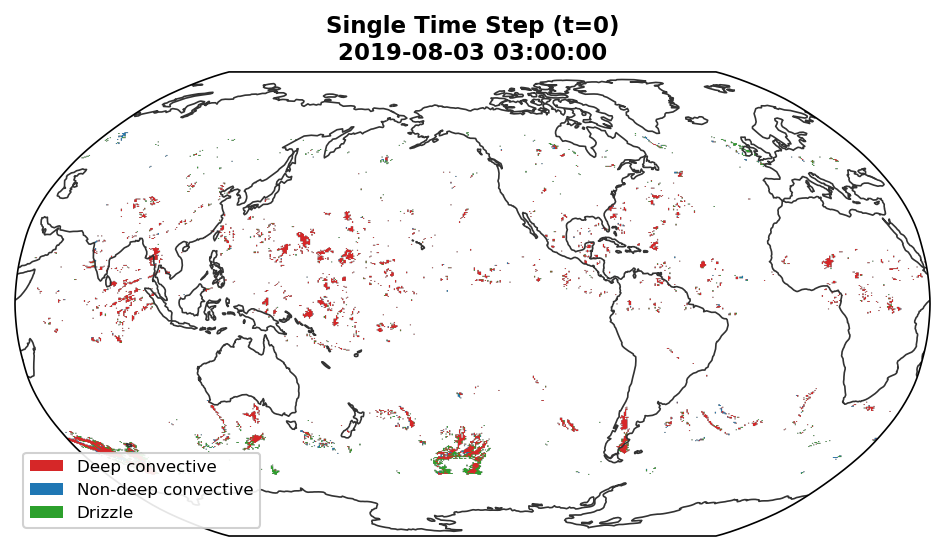

<Figure size 921.6x691.2 with 0 Axes>

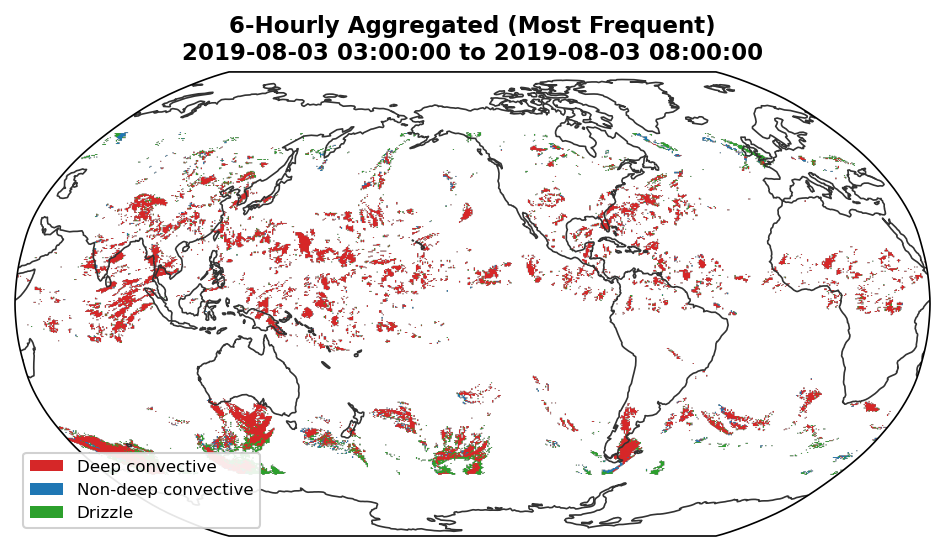

In [77]:
# Visualize the 6-hourly aggregated cloud type classification
# Note: egh.healpix_show creates its own projection, so we can't use subplot_kw with cartopy
# Instead, create separate plots

# Plot 1: Single time step (hour 0)
cloud_type_single = xr.DataArray(
    cloud_types_6h[0, :],
    dims=['cell'],
    coords={'cell': _ds['cell'], 'lat': _ds['lat'], 'lon': _ds['lon']}
)
ax1 = egh.healpix_show(cloud_type_single.where(cloud_type_single > 0), 
                       cmap=mpl.colors.ListedColormap([cloud_colors[i] for i in range(1, 4)]),
                       vmin=0.5, vmax=3.5,
                       dpi=150)
plt.title(f'Single Time Step (t=0)\n{_ds.time.values[0]}', fontsize=11, fontweight='bold')
legend_elements = [Patch(facecolor=cloud_colors[i], label=cloud_labels[i]) 
                   for i in range(1, 4)]
plt.legend(handles=legend_elements, loc='lower left', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

# Plot 2: 6-hourly aggregated
ax2 = egh.healpix_show(cloud_type_6h_da.where(cloud_type_6h_da > 0), 
                       cmap=mpl.colors.ListedColormap([cloud_colors[i] for i in range(1, 4)]),
                       vmin=0.5, vmax=3.5,
                       dpi=150)
plt.title(f'6-Hourly Aggregated (Most Frequent)\n{_ds.time.values[0]} to {_ds.time.values[-1]}', 
         fontsize=11, fontweight='bold')
plt.legend(handles=legend_elements, loc='lower left', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

**Note on Visualization:** The `egh.healpix_show()` function creates its own Robinson projection internally. When you pass `ax=ax` where the axes already has a cartopy projection (from `subplot_kw={'projection': ccrs.Robinson()}`), it conflicts and produces empty plots. The solution is to let `healpix_show()` create its own figure and axes, or use it without pre-defining a cartopy projection on the axes.

In [78]:
# Analyze temporal consistency - how many cells have the same type throughout the 6 hours
print("📈 Temporal Consistency Analysis:")
print("\nFor cells that were classified in at least one time step:")

# Get cells that had at least one non-zero classification
cells_with_clouds = np.any(cloud_types_6h > 0, axis=0)
n_cells_with_clouds = cells_with_clouds.sum()

# For each cell with clouds, check if it has the same type throughout
consistent_cells = np.zeros(cloud_types_6h.shape[1], dtype=bool)
for cell_idx in np.where(cells_with_clouds)[0]:
    cell_values = cloud_types_6h[:, cell_idx]
    # Get non-zero values only
    nonzero_values = cell_values[cell_values > 0]
    if len(nonzero_values) > 0:
        # Check if all non-zero values are the same
        if np.all(nonzero_values == nonzero_values[0]):
            consistent_cells[cell_idx] = True

n_consistent = consistent_cells.sum()
pct_consistent = 100 * n_consistent / n_cells_with_clouds if n_cells_with_clouds > 0 else 0

print(f"  Total cells with clouds: {n_cells_with_clouds:,}")
print(f"  Cells with consistent type: {n_consistent:,} ({pct_consistent:.1f}%)")
print(f"  Cells with changing type: {n_cells_with_clouds - n_consistent:,} ({100-pct_consistent:.1f}%)")

# Show distribution of number of unique types per cell
print("\nDistribution of number of unique types per cell:")
n_unique_types = []
for cell_idx in np.where(cells_with_clouds)[0]:
    cell_values = cloud_types_6h[:, cell_idx]
    nonzero_values = cell_values[cell_values > 0]
    if len(nonzero_values) > 0:
        n_unique = len(np.unique(nonzero_values))
        n_unique_types.append(n_unique)

for n in [1, 2, 3]:
    count = (np.array(n_unique_types) == n).sum()
    pct = 100 * count / len(n_unique_types) if len(n_unique_types) > 0 else 0
    print(f"  {n} type(s): {count:6,} cells ({pct:5.1f}%)")

📈 Temporal Consistency Analysis:

For cells that were classified in at least one time step:
  Total cells with clouds: 56,071
  Cells with consistent type: 49,069 (87.5%)
  Cells with changing type: 7,002 (12.5%)

Distribution of number of unique types per cell:
  Total cells with clouds: 56,071
  Cells with consistent type: 49,069 (87.5%)
  Cells with changing type: 7,002 (12.5%)

Distribution of number of unique types per cell:
  1 type(s): 49,069 cells ( 87.5%)
  2 type(s):  6,590 cells ( 11.8%)
  3 type(s):    412 cells (  0.7%)
  1 type(s): 49,069 cells ( 87.5%)
  2 type(s):  6,590 cells ( 11.8%)
  3 type(s):    412 cells (  0.7%)


## Summary & Full Dataset Application

The 6-hourly temporal aggregation successfully:
- Applies classification to each hourly snapshot
- Finds the most frequent cloud type for each cell over the 6-hour window
- Breaks ties using priority: deep_conv > nondeep_conv > drizzle
- Shows that 87.5% of cells maintain consistent cloud type, while 12.5% change types

To apply this to the entire dataset with 6-hourly output:

In [ ]:
# Function to process dataset in 6-hourly chunks
def process_6hourly_cloud_classification(ds, tb_thresh_da, start_idx=0, end_idx=None, window_size=6):
    """
    Process entire dataset in 6-hourly windows and classify cloud types.
    
    Parameters
    ----------
    ds : xarray.Dataset
        Dataset with tb, pr, mcs_mask, ccs_mask variables
    tb_thresh_da : xarray.DataArray
        Latitude-dependent temperature threshold
    start_idx : int
        Starting time index (default: 0)
    end_idx : int or None
        Ending time index (default: None, process all)
    window_size : int
        Size of temporal window in hours (default: 6)
        
    Returns
    -------
    cloud_type_6h_all : xarray.DataArray
        Cloud type classification for each 6-hour window
    """
    if end_idx is None:
        end_idx = len(ds.time)
    
    # Calculate number of windows
    n_windows = (end_idx - start_idx) // window_size
    if (end_idx - start_idx) % window_size != 0:
        n_windows += 1
    
    print(f"Processing {n_windows} windows of {window_size} hours each...")
    
    cloud_type_list = []
    time_list = []
    
    for w in range(n_windows):
        window_start = start_idx + w * window_size
        window_end = min(window_start + window_size, end_idx)
        
        print(f"\nWindow {w+1}/{n_windows}: time indices {window_start} to {window_end-1}")
        
        # Extract window
        ds_window = ds.isel(time=slice(window_start, window_end))
        
        # Apply classification to each time step
        cloud_types_window = []
        for t in range(len(ds_window.time)):
            tb_t = ds_window['tb'].isel(time=t)
            pr_t = ds_window['pr'].isel(time=t)
            mcs_mask_t = ds_window['mcs_mask'].isel(time=t)
            ccs_mask_t = ds_window['ccs_mask'].isel(time=t)
            
            nmcs_ccs_mask_t = ccs_mask_t.where(mcs_mask_t == 0)
            cloud_type_t = classify_cloud_types(tb_t, pr_t, tb_thresh_da, nmcs_ccs_mask_t, pr_threshold=0.5)
            
            cloud_types_window.append(cloud_type_t.values)
        
        # Stack and find most frequent
        cloud_types_window = np.stack(cloud_types_window, axis=0)
        cloud_type_agg = find_most_frequent_cloud_type(cloud_types_window)
        
        cloud_type_list.append(cloud_type_agg)
        # Use middle time of window
        time_list.append(ds_window.time.values[len(ds_window.time)//2])
        
        print(f"  Classified cells: {(cloud_type_agg > 0).sum():,}")
    
    # Stack all windows
    cloud_types_all = np.stack(cloud_type_list, axis=0)
    
    # Create xarray DataArray
    cloud_type_6h_all = xr.DataArray(
        cloud_types_all,
        dims=['time', 'cell'],
        coords={
            'time': time_list,
            'cell': ds['cell'],
            'lat': ds['lat'],
            'lon': ds['lon']
        },
        name='cloud_type_6h',
        attrs={
            'long_name': '6-hourly aggregated cloud type classification',
            'units': 'category',
            'flag_values': [0, 1, 2, 3],
            'flag_meanings': 'no_cloud deep_convective non-deep_convective drizzle',
            'description': 'Most frequent cloud type over 6-hour window',
            'priority_order': 'deep_convective > non-deep_convective > drizzle > no_cloud',
            'window_size': f'{window_size} hours'
        }
    )
    
    return cloud_type_6h_all

print("✅ Full dataset processing function ready")
print("\nTo apply to full dataset:")
print("  cloud_type_6h_full = process_6hourly_cloud_classification(ds, tb_thresh_da)")
print("  # Or for a subset:")
print("  cloud_type_6h_subset = process_6hourly_cloud_classification(ds, tb_thresh_da, start_idx=0, end_idx=100)")